In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
df = pd.read_excel("GalleryExhibitions.xlsx")

In [3]:
df

,Title,Artist,Date Made,Date acquired,Date Exhibited,Artwork type,Viewer Rating
0,Abstract Horizon,Aaron Delgado,1998,2005-03-12,2008-06-01,Painting,4.8
1,Silent Forest,Bianca Holloway,2001,2007-07-21,2010-06-01,Painting,3.9
2,Urban Rhythm,Caleb Thornton,2010,2014-09-10,2016-09-15,Digital Art,4.5
3,Golden Fields,Daniela Vargas,1995,2002-05-16,2006-03-20,Painting,2.7
4,Fragmented Form,Ethan Whitaker,2016,2019-11-02,2021-11-10,Sculpture,4.1
...,...,...,...,...,...,...,...
143,Digital Tide II,Valerie King,2021,2023-07-01,2024-09-15,Digital Art,4.5
144,Silent Avenue,Walter Diaz,2010,2014-09-02,2016-09-15,Photograph,3.4
145,Bright Valley,Xena Patel,2001,2006-07-07,2008-06-01,Painting,4.1
146,Stone Field,Yusuf Karim,2003,2007-11-11,2009-06-01,Sculpture,2.8


In [4]:
print ("These are all the artworks that have been exhibited at the gallery over the years [1996-2024]")
pd.set_option('display.max_rows', 148)
df

These are all the artworks that have been exhibited at the gallery over the years [1996-2024]


,Title,Artist,Date Made,Date acquired,Date Exhibited,Artwork type,Viewer Rating
0,Abstract Horizon,Aaron Delgado,1998,2005-03-12,2008-06-01,Painting,4.8
1,Silent Forest,Bianca Holloway,2001,2007-07-21,2010-06-01,Painting,3.9
2,Urban Rhythm,Caleb Thornton,2010,2014-09-10,2016-09-15,Digital Art,4.5
3,Golden Fields,Daniela Vargas,1995,2002-05-16,2006-03-20,Painting,2.7
4,Fragmented Form,Ethan Whitaker,2016,2019-11-02,2021-11-10,Sculpture,4.1
5,Blue Motion,Farah Mahmoud,2008,2012-02-18,2014-02-14,Painting,3.3
6,Echoes of Time,Gavin Schroeder,1992,2000-06-23,2003-05-10,Painting,4.9
7,City Lights,Hannah Leblanc,2015,2018-08-12,2019-09-15,Photograph,3.8
8,Rust & Steel,Isaac Navarro,2003,2010-04-30,2011-06-01,Sculpture,2.5
9,Still Water,Jasmine Okoye,1999,2006-12-01,2009-11-10,Painting,4.2


In [5]:
df['Date Exhibited'] = pd.to_datetime(df['Date Exhibited'])
df['Year'] = df['Date Exhibited'].dt.year

table = df.groupby(['Year','Artwork type']).size().unstack(fill_value=0)

print(table)

Artwork type  Digital Art  Painting  Photograph  Sculpture
Year                                                      
1996                    0         1           0          0
1998                    0         1           0          0
1999                    0         1           0          0
2002                    0         2           0          0
2003                    0         3           0          0
2004                    0         1           1          0
2005                    0         5           0          0
2006                    0         5           0          2
2007                    0         5           0          0
2008                    0         5           0          0
2009                    0         4           0          3
2010                    0         5           0          2
2011                    0         4           0          4
2012                    0         3           0          2
2013                    0         1           0         

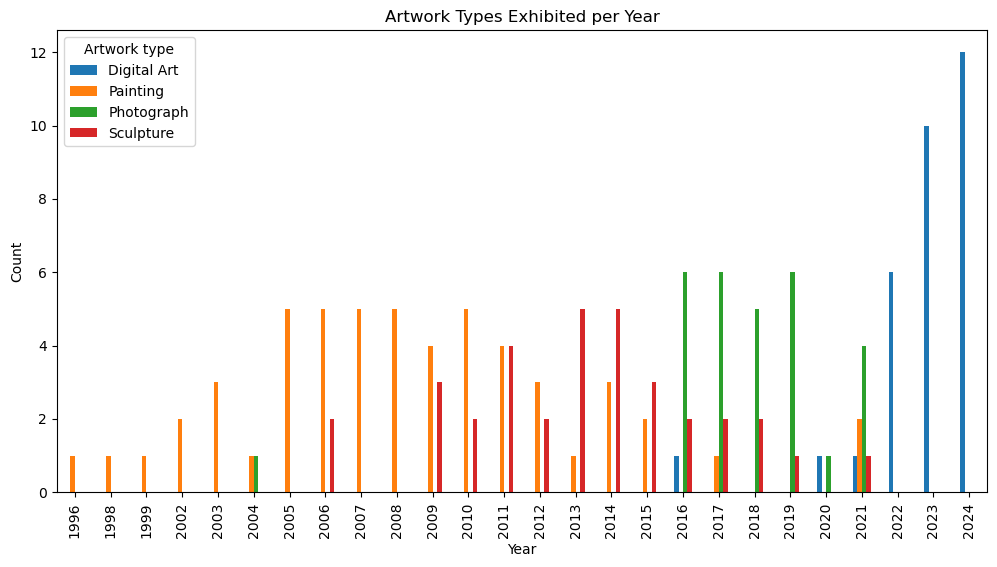

In [6]:
table.plot(kind='bar', figsize=(12,6))

plt.title('Artwork Types Exhibited per Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.savefig('ArtworkTypes_PerYear.png')
plt.show()



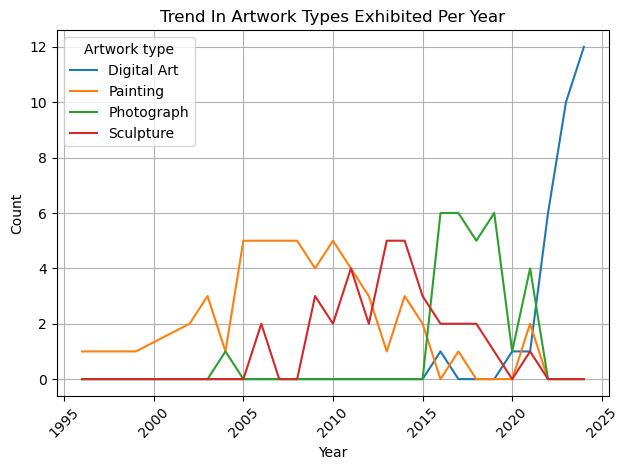

In [7]:
table.plot(kind='line')

plt.title('Trend In Artwork Types Exhibited Per Year')
plt.xlabel('Year')
plt.ylabel('Count')

plt.xticks(rotation=45)
plt.grid()

plt.tight_layout()
plt.show()

In [8]:
df['Date Exhibited'] = pd.to_datetime(df['Date Exhibited'])
df['Year'] = df['Date Exhibited'].dt.year

best_per_year = df.loc[df.groupby('Year')['Viewer Rating'].idxmax()]
best_per_year = best_per_year.sort_values('Year')
print(best_per_year[['Year', 'Title', 'Viewer Rating']])

     Year             Title  Viewer Rating
22   1996     Crimson Study            3.1
10   1998      Ancient Path            3.7
30   1999    Golden Silence            4.9
60   2002      Sunset Study            4.6
6    2003    Echoes of Time            4.9
14   2004  Quiet Reflection            3.6
38   2005    Morning Valley            4.6
106  2006       Blue Garden            4.2
129  2007     Golden Valley            4.3
0    2008  Abstract Horizon            4.8
89   2009        Golden Sky            4.5
93   2010        River Glow            4.1
137  2011         Red Bloom            4.2
13   2012     Sunlit Valley            4.4
76   2013        Red Valley            3.9
24   2014     Pastel Dreams            4.5
16   2015       Ocean Pulse            4.7
2    2016      Urban Rhythm            4.5
20   2017      Nigh Streets            3.5
29   2018   Captured Moment            4.0
7    2019       City Lights            3.8
37   2020        Light Echo            3.9
126  2021  

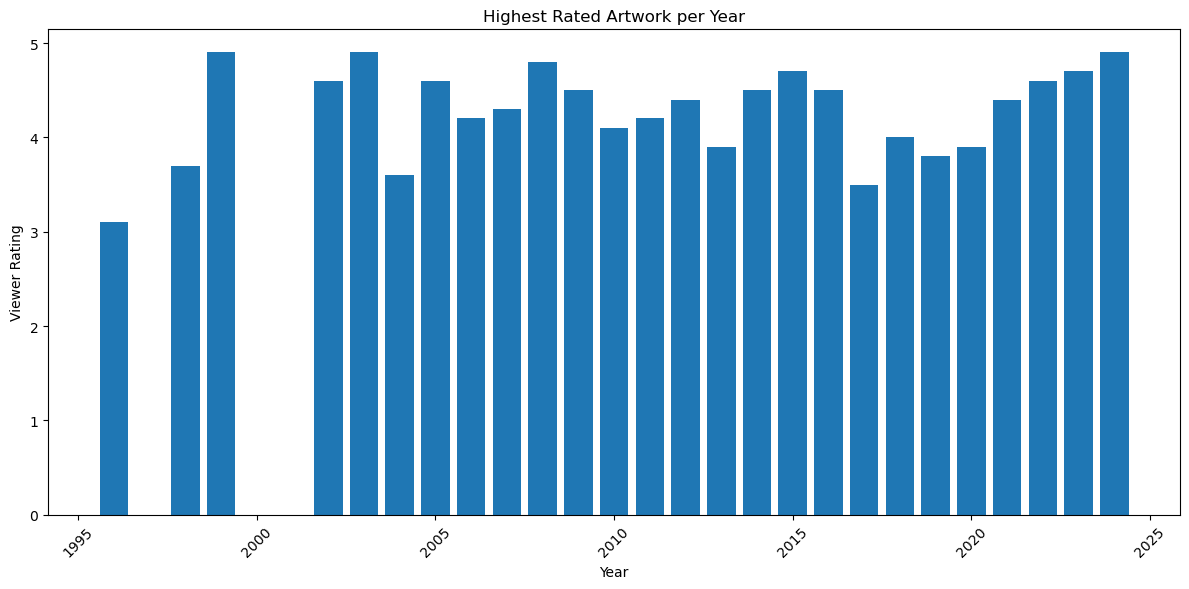

In [9]:
plt.figure(figsize=(12,6))

plt.bar(best_per_year['Year'], best_per_year['Viewer Rating'])

plt.title('Highest Rated Artwork per Year')
plt.xlabel('Year')
plt.ylabel('Viewer Rating')

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('Highest_RatedArtwork.png')
plt.show()

In [10]:
df['Date Exhibited'] = pd.to_datetime(df['Date Exhibited'])
df['Year'] = df['Date Exhibited'].dt.year

pivot = df.groupby('Year').size().reset_index(name='Total Artworks')

print(pivot)


    Year  Total Artworks
0   1996               1
1   1998               1
2   1999               1
3   2002               2
4   2003               3
5   2004               2
6   2005               5
7   2006               7
8   2007               5
9   2008               5
10  2009               7
11  2010               7
12  2011               8
13  2012               5
14  2013               6
15  2014               8
16  2015               5
17  2016               9
18  2017               9
19  2018               7
20  2019               7
21  2020               2
22  2021               8
23  2022               6
24  2023              10
25  2024              12


In [11]:
max_year = pivot.loc[pivot['Total Artworks'].idxmax()]
print(max_year)

Year              2024
Total Artworks      12
Name: 25, dtype: int64


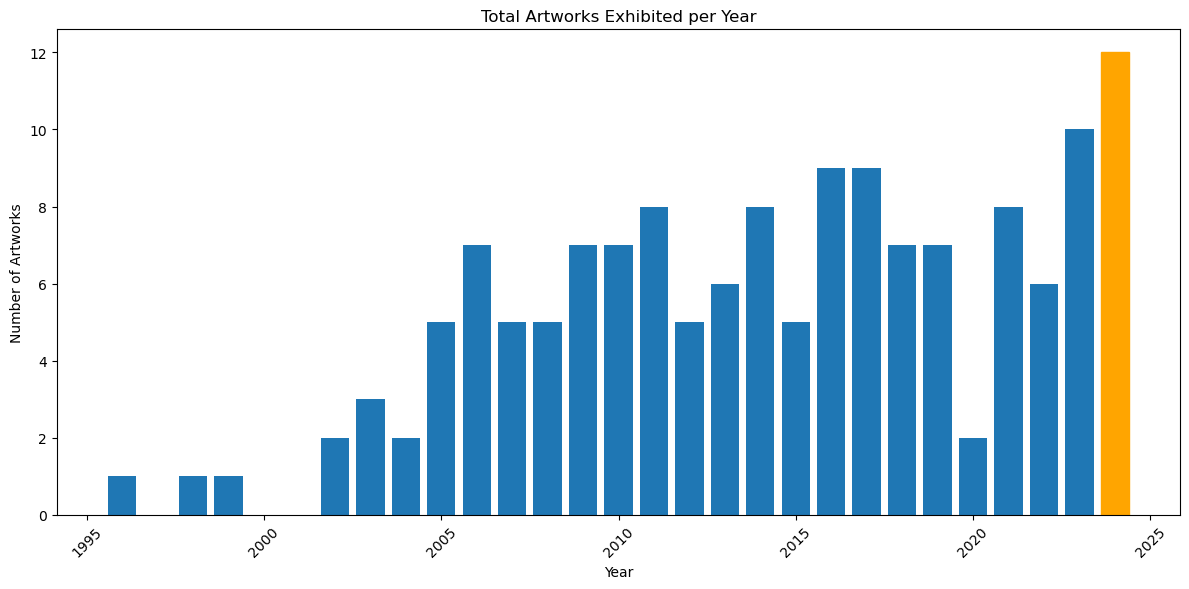

In [12]:
plt.figure(figsize=(12,6))

bars = plt.bar(pivot['Year'], pivot['Total Artworks'])

max_idx = pivot['Total Artworks'].idxmax()
bars[max_idx].set_color('orange')


plt.title('Total Artworks Exhibited per Year')
plt.xlabel('Year')
plt.ylabel('Number of Artworks')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

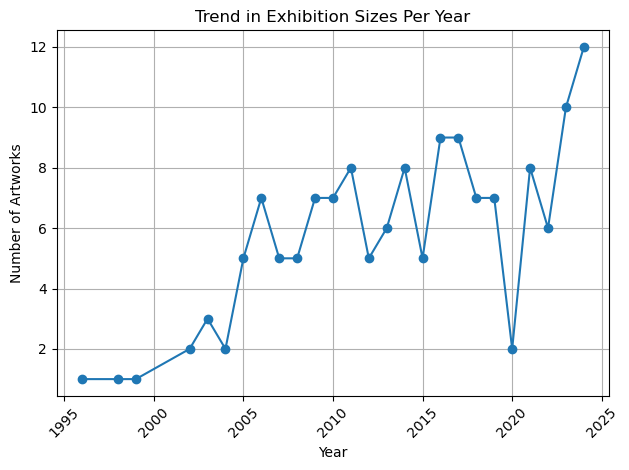

In [13]:

df['Date Exhibited'] = pd.to_datetime(df['Date Exhibited'])
df['Year'] = df['Date Exhibited'].dt.year
yearly_counts = df.groupby('Year').size().reset_index(name='Total Artworks')


plt.plot(yearly_counts['Year'], yearly_counts['Total Artworks'], marker='o')

plt.title('Trend in Exhibition Sizes Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Artworks')

plt.xticks(rotation=45)
plt.grid()


plt.tight_layout()
plt.savefig('Exhibition_Sizes.png')
plt.show()